# HRV Analysis
Analysis of recorded data, to later translate to C++ for real-time processing.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv('hrv_data_20260310_212416.csv')

# Display basic information
print(f"Total samples: {len(df)}")
print(f"Duration: {df['timestamp_ms'].iloc[-1] / 1000:.2f} seconds")
print(f"Sample rate: {len(df) / (df['timestamp_ms'].iloc[-1] / 1000):.1f} Hz")
print("\nFirst few rows:")
df.head()

Total samples: 4000
Duration: 11.76 seconds
Sample rate: 340.0 Hz

First few rows:


,timestamp_ms,timestamp_abs,ir_value
0,1705.6262,1.773174e+09,119456.0
1,1707.3466,1.773174e+09,119477.0
2,1710.2059,1.773174e+09,119465.0
3,1711.8666,1.773174e+09,119501.0
4,1715.1352,1.773174e+09,119476.0


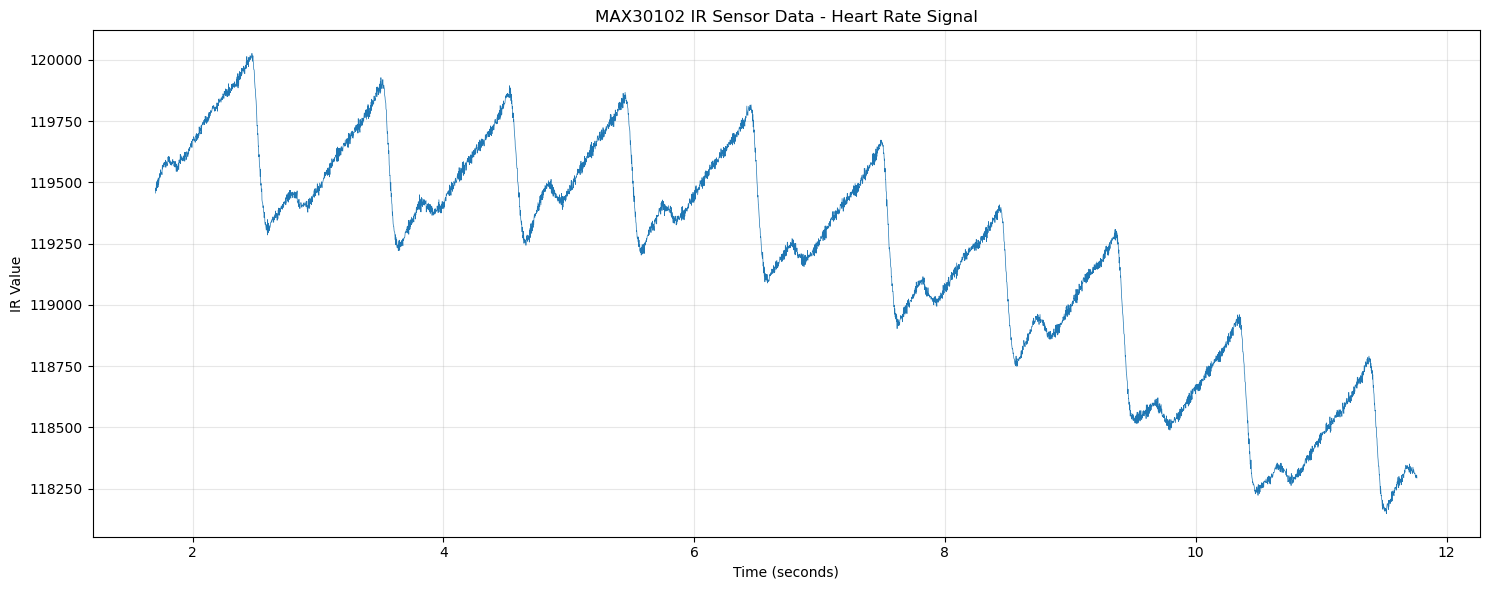

In [27]:
# Plot IR value over time
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp_ms'] / 1000, df['ir_value'], linewidth=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('IR Value')
plt.title('MAX30102 IR Sensor Data - Heart Rate Signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Why Bandpass Filter?


**Bandpass Filter (0.5-5 Hz)** is the industry standard for PPG heart rate signals because:

1. **Known Frequency Range**: Heart rate frequencies are well-defined (30-300 BPM = 0.5-5 Hz)
2. **Removes Baseline Drift**: Low-frequency components (<0.5 Hz) from motion and breathing
3. **Removes High-Frequency Noise**: Electrical noise and sensor artifacts (>5 Hz)
4. **Preserves Peak Shape**: Critical for accurate R-R interval detection in HRV analysis
5. **Computationally Efficient**: Easy to implement in real-time on embedded systems (C++)


In [28]:
from scipy import signal
from scipy.signal import butter, filtfilt

# This isolates the heart rate frequency range and removes low-frequency drift and high-frequency noise

# Calculate actual sample rate
sample_rate = len(df) / (df['timestamp_ms'].iloc[-1] / 1000)
print(f"Estimated sample rate: {sample_rate:.1f} Hz")

# Design bandpass filter for heart rate (0.5 - 5 Hz)
# This covers heart rates from 30 to 300 BPM
lowcut = 0.5  # Hz
highcut = 5.0  # Hz
order = 4

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    y = filtfilt(b, a, data)
    return y

# Apply bandpass filter
ir_filtered = apply_bandpass_filter(df['ir_value'].values, lowcut, highcut, sample_rate, order)

# Add to dataframe
df['ir_filtered'] = ir_filtered

print(f"\nBandpass filter applied: {lowcut} - {highcut} Hz")
print(f"This isolates heart rate frequencies (30-300 BPM)")

Estimated sample rate: 340.0 Hz

Bandpass filter applied: 0.5 - 5.0 Hz
This isolates heart rate frequencies (30-300 BPM)


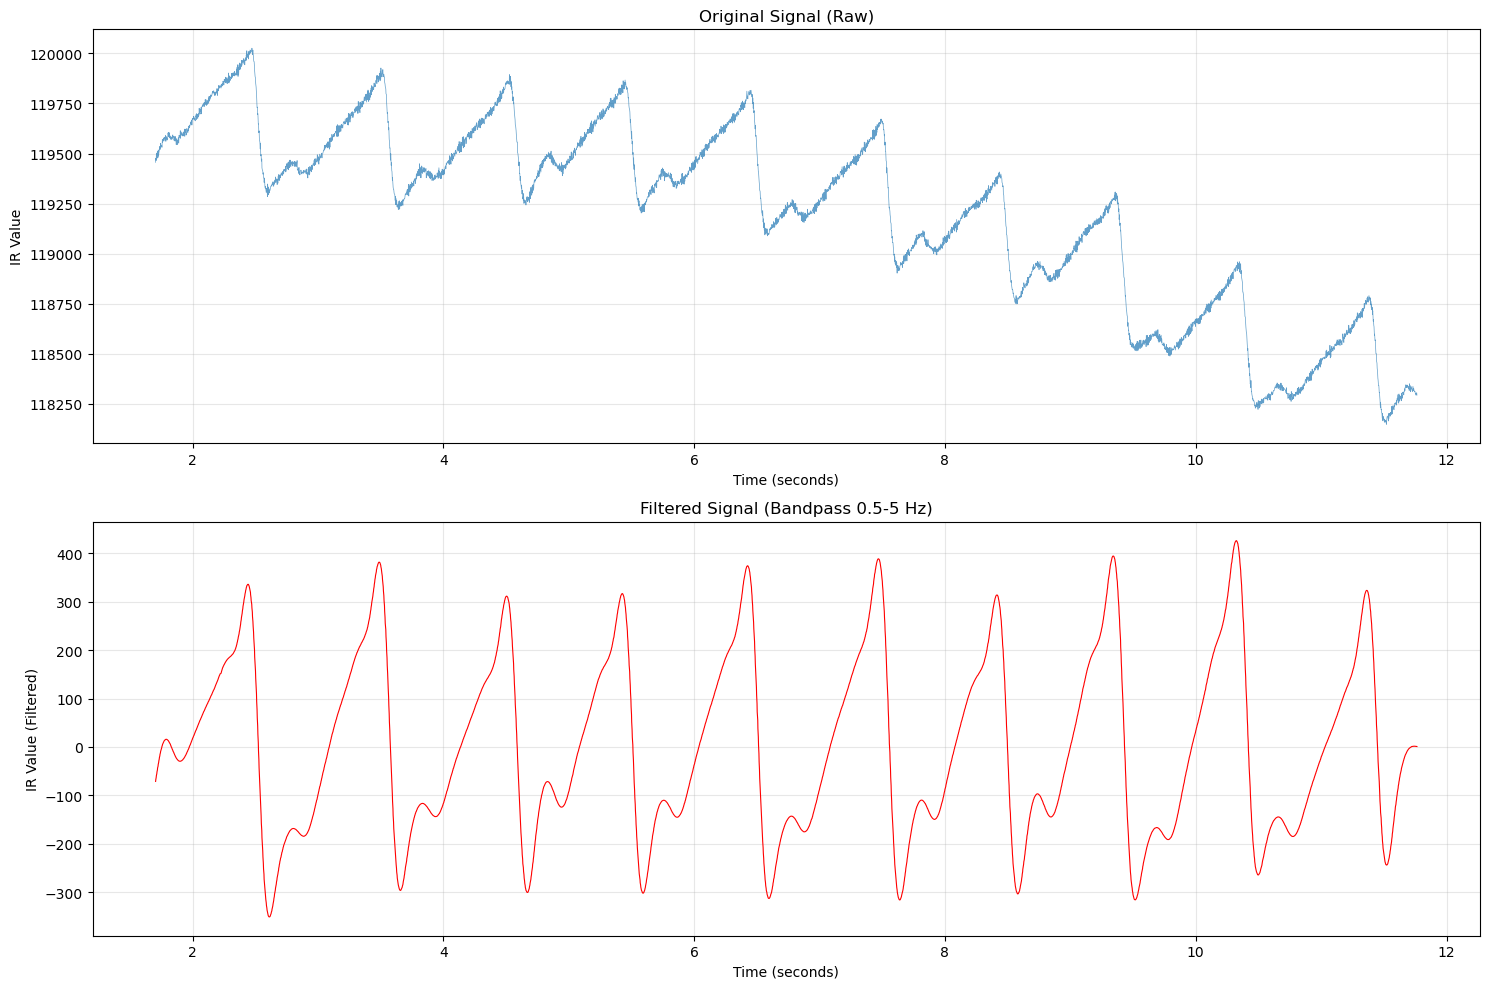

In [29]:
# Comparison plot: Original vs Filtered
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Original signal
axes[0].plot(df['timestamp_ms'] / 1000, df['ir_value'], linewidth=0.5, alpha=0.7)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('IR Value')
axes[0].set_title('Original Signal (Raw)')
axes[0].grid(True, alpha=0.3)

# Filtered signal
axes[1].plot(df['timestamp_ms'] / 1000, df['ir_filtered'], linewidth=0.8, color='red')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('IR Value (Filtered)')
axes[1].set_title('Filtered Signal (Bandpass 0.5-5 Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Peak detection on entire dataset
from scipy.signal import find_peaks

# Peak detection parameters
min_distance = int(sample_rate * 0.4)  # Minimum 0.4s between peaks (max 150 BPM)
min_prominence_original = 50  # Minimum prominence for raw signal
min_prominence_filtered = np.std(df['ir_filtered']) * 0.3  # Adaptive for filtered

# Detect peaks in ORIGINAL signal
peaks_original, props_original = find_peaks(
    df['ir_value'].values, 
    distance=min_distance,
    prominence=min_prominence_original
)

# Detect peaks in FILTERED signal
peaks_filtered, props_filtered = find_peaks(
    df['ir_filtered'].values, 
    distance=min_distance,
    prominence=min_prominence_filtered
)

# Calculate statistics
duration_sec = df['timestamp_ms'].iloc[-1] / 1000
bpm_original = (len(peaks_original) / duration_sec) * 60
bpm_filtered = (len(peaks_filtered) / duration_sec) * 60

print("=" * 70)
print("PEAK DETECTION RESULTS (Entire Dataset)")
print("=" * 70)
print(f"\nDataset Duration: {duration_sec:.1f} seconds ({duration_sec/60:.1f} minutes)")
print(f"\nORIGINAL Signal:")
print(f"  Peaks detected: {len(peaks_original)}")
print(f"  Average heart rate: {bpm_original:.1f} BPM")
print(f"  Peak prominence threshold: {min_prominence_original}")

print(f"\nFILTERED Signal:")
print(f"  Peaks detected: {len(peaks_filtered)}")
print(f"  Average heart rate: {bpm_filtered:.1f} BPM")
print(f"  Peak prominence threshold: {min_prominence_filtered:.2f}")

print(f"\nDifference: {abs(len(peaks_original) - len(peaks_filtered))} peaks")
print("=" * 70)

PEAK DETECTION RESULTS (Entire Dataset)

Dataset Duration: 11.8 seconds (0.2 minutes)

ORIGINAL Signal:
  Peaks detected: 13
  Average heart rate: 66.3 BPM
  Peak prominence threshold: 50

FILTERED Signal:
  Peaks detected: 10
  Average heart rate: 51.0 BPM
  Peak prominence threshold: 55.29

Difference: 3 peaks


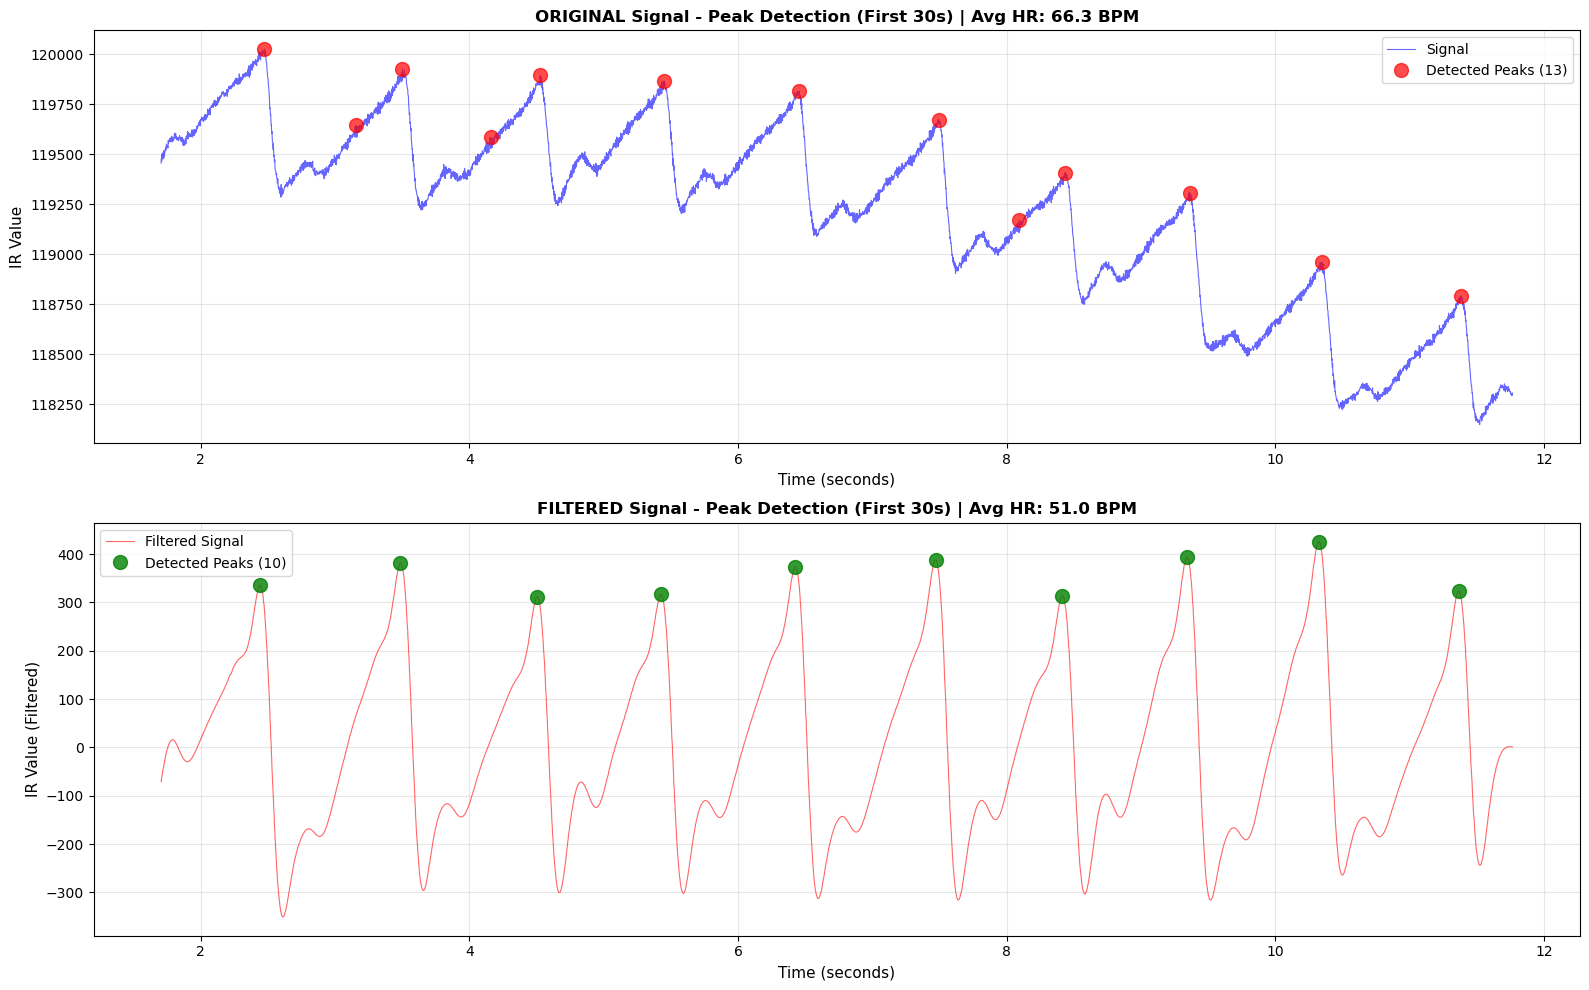


In first 30 seconds:
  Original: 13 peaks | Expected: ~25 peaks
  Filtered: 10 peaks | Expected: ~25 peaks


In [31]:
# Visualize peak detection - Zoomed view (first 30 seconds)
time_window = 30  # seconds
mask = df['timestamp_ms'] <= (time_window * 1000)
mask_indices = np.where(mask)[0]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ORIGINAL signal with detected peaks
peaks_in_window_orig = [p for p in peaks_original if p in mask_indices]
axes[0].plot(df[mask]['timestamp_ms'] / 1000, df[mask]['ir_value'], 
             linewidth=0.8, alpha=0.6, color='blue', label='Signal')
axes[0].plot(df.iloc[peaks_in_window_orig]['timestamp_ms'] / 1000, 
             df.iloc[peaks_in_window_orig]['ir_value'], 
             'ro', markersize=10, alpha=0.7, label=f'Detected Peaks ({len(peaks_in_window_orig)})')
axes[0].set_xlabel('Time (seconds)', fontsize=11)
axes[0].set_ylabel('IR Value', fontsize=11)
axes[0].set_title(f'ORIGINAL Signal - Peak Detection (First {time_window}s) | Avg HR: {bpm_original:.1f} BPM', 
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# FILTERED signal with detected peaks
peaks_in_window_filt = [p for p in peaks_filtered if p in mask_indices]
axes[1].plot(df[mask]['timestamp_ms'] / 1000, df[mask]['ir_filtered'], 
             linewidth=0.8, alpha=0.6, color='red', label='Filtered Signal')
axes[1].plot(df.iloc[peaks_in_window_filt]['timestamp_ms'] / 1000, 
             df.iloc[peaks_in_window_filt]['ir_filtered'], 
             'go', markersize=10, alpha=0.8, label=f'Detected Peaks ({len(peaks_in_window_filt)})')
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('IR Value (Filtered)', fontsize=11)
axes[1].set_title(f'FILTERED Signal - Peak Detection (First {time_window}s) | Avg HR: {bpm_filtered:.1f} BPM', 
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nIn first {time_window} seconds:")
print(f"  Original: {len(peaks_in_window_orig)} peaks | Expected: ~{int(time_window * bpm_filtered / 60)} peaks")
print(f"  Filtered: {len(peaks_in_window_filt)} peaks | Expected: ~{int(time_window * bpm_filtered / 60)} peaks")

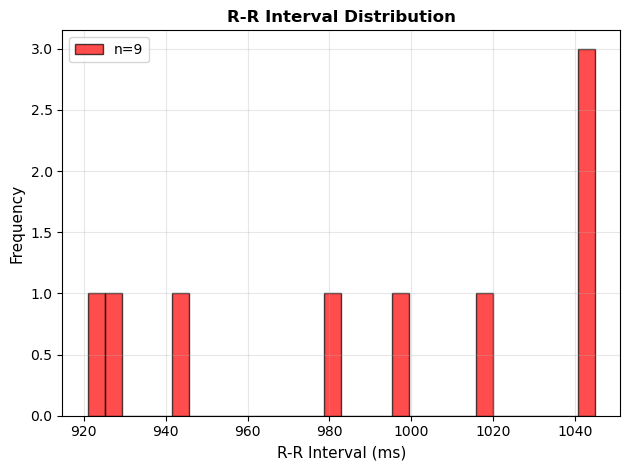


R-R INTERVAL STATISTICS (HRV Metrics)

Total R-R intervals: 9
Mean R-R: 991.1 ms
Std Dev (SDNN): 47.5 ms
Min R-R: 921.0 ms
Max R-R: 1044.8 ms
Range: 123.8 ms

Mean Heart Rate: 60.5 BPM


In [32]:
# R-R Intervals (Inter-Beat Intervals) Analysis
# Calculate R-R intervals from peak timestamps
rr_intervals = np.diff(df.iloc[peaks_filtered]['timestamp_ms'].values)

plt.hist(rr_intervals, bins=30, alpha=0.7, color='red', 
             label=f'n={len(rr_intervals)}', edgecolor='black')
plt.xlabel('R-R Interval (ms)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('R-R Interval Distribution', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Calculate HRV metrics
print("\n" + "=" * 70)
print("R-R INTERVAL STATISTICS (HRV Metrics)")
print("=" * 70)
print(f"\nTotal R-R intervals: {len(rr_intervals)}")
print(f"Mean R-R: {np.mean(rr_intervals):.1f} ms")
print(f"Std Dev (SDNN): {np.std(rr_intervals):.1f} ms")
print(f"Min R-R: {np.min(rr_intervals):.1f} ms")
print(f"Max R-R: {np.max(rr_intervals):.1f} ms")
print(f"Range: {np.max(rr_intervals) - np.min(rr_intervals):.1f} ms")
print(f"\nMean Heart Rate: {60000 / np.mean(rr_intervals):.1f} BPM")
print("=" * 70)

## Translation to ESP32 C++ Code

```C
Hello Ligma
```